# Single cell MODFLOW model - Linear Recharge

This notebook shows how to use a single cell MODFLOW model with a GHB (general head boundary) and RCH (recharge) package as a stressmodel in Pastas. The MODFLOW model implements the same physics as the Pastas exponential response function.

## Packages

In [1]:
import logging
from pathlib import Path

import flopy
import numpy as np
import pandas as pd
import pastas as ps
from pastas.timer import SolveTimer

from pastas_plugins import modflow as ppmf

bindir = Path("bin")
if not (bindir / "mf6").exists():
    bindir.mkdir(parents=True, exist_ok=True)
    flopy.utils.get_modflow(bindir, repo="modflow6-nightly-build")

In [2]:
ppmf.set_log_level(logging.ERROR)

ps.set_use_cache(True)

## Load Data

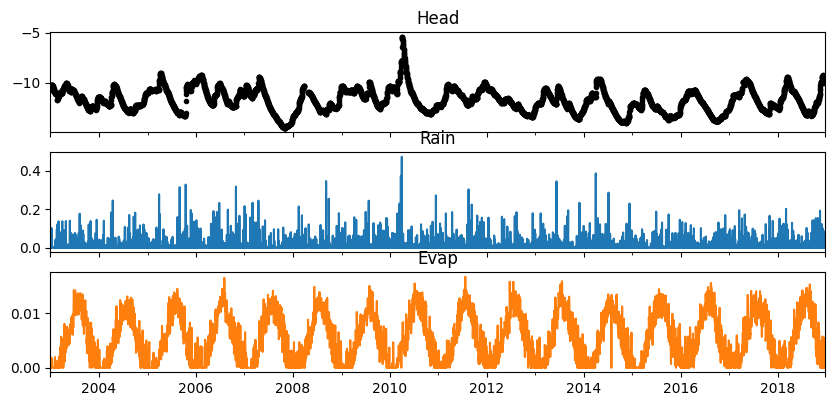

In [3]:
ds = {
    "rain": pd.read_csv("rain.csv", index_col=0, parse_dates=True),
    "head": pd.read_csv("head.csv", index_col=0, parse_dates=True),
    "evap": pd.read_csv("evap.csv", index_col=0, parse_dates=True),
}
head = ds["head"].squeeze().dropna()
prec = ds["rain"].squeeze().dropna().resample("D").asfreq().fillna(0.0)
evap = ds["evap"].squeeze().dropna()

ps.plots.series(head, [prec, evap], hist=False);

## Time series models

### Standard exponential model

Fit report Head                     Fit Statistics
nfev     11                     EVP          87.10
nobs     5737                   R2            0.87
noise    False                  RMSE          0.42
tmin     2003-01-01 00:00:00    AICc      -9870.13
tmax     2018-12-25 00:00:00    BIC       -9843.52
freq     D                      Obj         512.71
freq_obs None                   ___               
warmup   3650 days 00:00:00     Interp.         No

Parameters (4 optimized)
               optimal    initial  vary
rch_A       331.307215  29.925748  True
rch_a        98.429448  10.000000  True
rch_f        -0.854497  -1.000000  True
constant_d  -14.150450 -11.740288  True


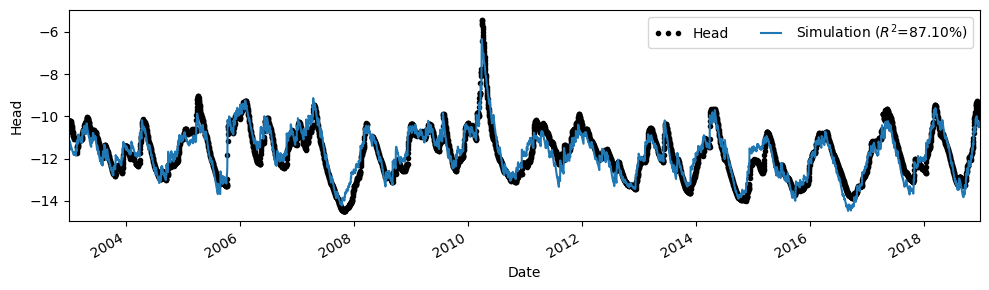

In [4]:
mlexp = ps.Model(head)
mlexp.add_stressmodel(
    ps.RechargeModel(prec=prec, evap=evap, rfunc=ps.Exponential(), name="rch")
)
mlexp.solve()
mlexp.plot(figsize=(10, 3));

### Uncalibrated MODFLOW time series model

Using parameters derived from the Pastas Exponential model (GHB conductance ≈ `rch_A`, storage ≈ `rch_a / rch_A`, evaporation factor ≈ `rch_f`).

In [5]:
mlexp_c = mlexp.parameters.loc["rch_A", "optimal"]
mlexp_c_i = mlexp.parameters.loc["rch_A", "initial"]
mlexp_s = (
    mlexp.parameters.loc["rch_a", "optimal"] / mlexp.parameters.loc["rch_A", "optimal"]
)
mlexp_s_i = (
    mlexp.parameters.loc["rch_a", "initial"] / mlexp.parameters.loc["rch_A", "initial"]
)
mlexp_d = mlexp.parameters.loc["constant_d", "optimal"]
mlexp_d_i = mlexp.parameters.loc["constant_d", "initial"]
mlexp_f = mlexp.parameters.loc["rch_f", "optimal"]
mlexp_f_i = mlexp.parameters.loc["rch_f", "initial"]

Model is not optimized yet, initial parameters are used.


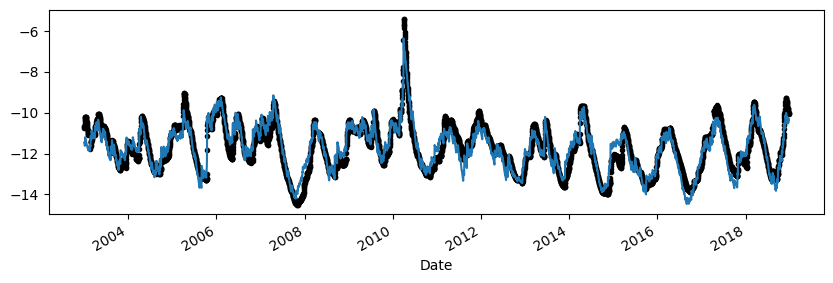

In [6]:
# create modflow pastas model with c and sy
mlexpmf = ps.Model(head)
mlexpmf.settings["warmup"] = pd.Timedelta(days=4 * 365)
mfml_init = ppmf.ModflowModel(
    model=mlexpmf,
    exe_name=bindir / "mf6",
    sim_ws=Path("mftest_init"),
    silent=True,
)
ghb_init = ppmf.ModflowGhb()
rch_init = ppmf.ModflowRch(prec, evap)
mfml_init.add_modflow_package([ghb_init, rch_init])
mlexpmf.add_stressmodel(mfml_init)
mlexpmf.set_parameter("constant_d", initial=mlexp_d, vary=False)
mlexpmf.set_parameter("GHB_C", initial=1 / mlexp_c, vary=False)
mlexpmf.set_parameter("STO_S", initial=mlexp_s, vary=False)
mlexpmf.set_parameter("RCH_f", initial=mlexp_f, vary=False)

sim = mlexpmf.simulate()
ax = mlexpmf.observations().plot(
    marker=".", color="k", linestyle="None", legend=False, figsize=(10, 3)
)
sim.plot(ax=ax);

In [7]:
mlexpmf.parameters

,initial,pmin,pmax,vary,name,package,dist,stderr,optimal
DIS_H,0.000000,0.00000,10.00000,False,mfsm,DIS,uniform,NaN,NaN
STO_S,0.297094,0.00100,0.50000,False,mfsm,STO,uniform,NaN,NaN
constant_d,-14.150450,-15.67716,-4.24284,False,mfsm,GHB,uniform,NaN,NaN
GHB_C,0.003018,0.00001,0.10000,False,mfsm,GHB,uniform,NaN,NaN
RCH_f,-0.854497,-2.00000,0.00000,False,mfsm,RCH,uniform,NaN,NaN


## Calibrated MODFLOW time series model

Now fit a Pastas Model using the Modflow model as a response function. This takes some
time, as the modflow model has to be recomputed for every iteration in the optimization
process.

In [8]:
ml = ps.Model(head)
ml.settings["warmup"] = pd.Timedelta(days=4 * 365)
mfml = ppmf.ModflowModel(
    model=ml,
    exe_name=bindir / "mf6",
    sim_ws=Path("mftest"),
    silent=True,
)
ghb = ppmf.ModflowGhb()
rch = ppmf.ModflowRch(prec, evap)
mfml.add_modflow_package([ghb, rch])
ml.add_stressmodel(mfml)
ml.set_parameter("GHB_C", initial=1 / mlexp_c_i)
ml.set_parameter("STO_S", initial=mlexp_s_i)
ml.set_parameter("RCH_f", initial=mlexp_f_i)

with SolveTimer() as t:
    ml.solve(diff_step=1e-4, callback=t.timer)

Optimization progress: 0it [00:00, ?it/s]

Fit report Head                     Fit Statistics
nfev     22                     EVP          87.09
nobs     5737                   R2            0.87
noise    False                  RMSE          0.42
tmin     2003-01-01 00:00:00    AICc      -9866.39
tmax     2018-12-25 00:00:00    BIC       -9839.78
freq     D                      Obj         513.05
freq_obs None                   ___               
warmup   3650 days 00:00:00     Interp.         No

Parameters (4 optimized)
              optimal    initial   vary
DIS_H        0.000000   0.000000  False
STO_S        0.295460   0.334160   True
constant_d -14.153977 -11.740288   True
GHB_C        0.003019   0.033416   True
RCH_f       -0.853424  -1.000000   True

Warnings! (1)
Parameter 'DIS_H' on lower bound: 0.00e+00


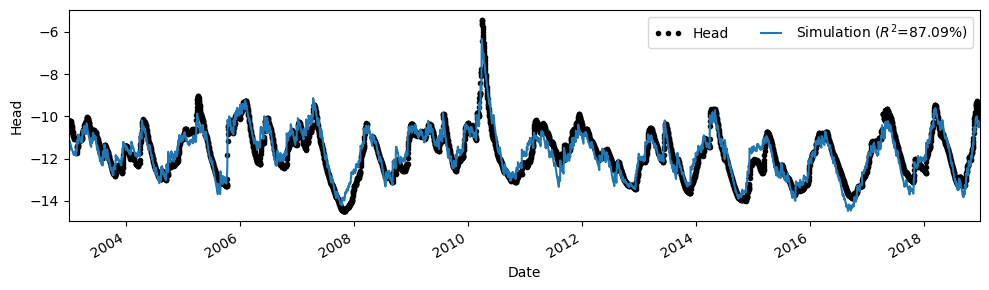

In [9]:
ml.plot(figsize=(10, 3));

## Results

### Parameters

In [10]:
ml.parameters.style.set_table_attributes('style="font-size: 12px"').set_caption(
    "Pastas-Modflow"
)

,initial,pmin,pmax,vary,name,package,dist,stderr,optimal
DIS_H,0.000000,0.000000,10.000000,False,mfsm,DIS,uniform,nan,0.000000
STO_S,0.334160,0.001000,0.500000,True,mfsm,STO,uniform,0.002476,0.295460
constant_d,-11.740288,-15.677160,-4.242840,True,mfsm,GHB,uniform,0.035426,-14.153977
GHB_C,0.033416,0.000010,0.100000,True,mfsm,GHB,uniform,0.000027,0.003019
RCH_f,-1.000000,-2.000000,0.000000,True,mfsm,RCH,uniform,0.011259,-0.853424


In [11]:
mlexp.parameters.style.set_table_attributes('style="font-size: 12px"').set_caption(
    "Pastas-Exponential"
)

,initial,pmin,pmax,vary,name,dist,stderr,optimal
rch_A,29.925748,0.000010,2992.574763,True,rch,uniform,2.902510,331.307215
rch_a,10.000000,0.010000,10000.000000,True,rch,uniform,0.948456,98.429448
rch_f,-1.000000,-2.000000,0.000000,True,rch,uniform,0.011335,-0.854497
constant_d,-11.740288,nan,nan,True,constant,uniform,0.035350,-14.150450


Compare parameters from the Pastas-Modflow model to the "true" parameters derived from
the Pastas exponential model.

In [12]:
mlexpmf.parameters

,initial,pmin,pmax,vary,name,package,dist,stderr,optimal
DIS_H,0.000000,0.00000,10.00000,False,mfsm,DIS,uniform,NaN,NaN
STO_S,0.297094,0.00100,0.50000,False,mfsm,STO,uniform,NaN,NaN
constant_d,-14.150450,-15.67716,-4.24284,False,mfsm,GHB,uniform,NaN,NaN
GHB_C,0.003018,0.00001,0.10000,False,mfsm,GHB,uniform,NaN,NaN
RCH_f,-0.854497,-2.00000,0.00000,False,mfsm,RCH,uniform,NaN,NaN


In [13]:
comparison = pd.DataFrame(
    {
        "True": np.full_like(ml.parameters["optimal"].values, np.nan),
        "MF6": ml.parameters["optimal"].values,
    },
    index=ml.parameters.index,
)
comparison.loc["GHB_C", "True"] = 1 / mlexp.parameters.loc["rch_A", "optimal"]
comparison.loc["STO_S", "True"] = (
    mlexp.parameters.loc["rch_a", "optimal"] / mlexp.parameters.loc["rch_A", "optimal"]
)
comparison.loc["RCH_f", "True"] = mlexp.parameters.loc["rch_f", "optimal"]
comparison.loc["constant_d", "True"] = mlexp.parameters.loc["constant_d", "optimal"]


comparison["Difference"] = comparison["MF6"] - comparison["True"]
comparison["% Difference"] = (comparison["Difference"] / comparison["True"]) * 100
comparison.iloc[1:].style.format(
    {
        "True": "{:.2e}",
        "MF6": "{:.2e}",
        "Difference": "{:.2f}",
        "% Difference": "{:.2f}",
    }
)  # do not show H

,True,MF6,Difference,% Difference
STO_S,2.97e-01,2.95e-01,-0.00,-0.55
constant_d,-1.42e+01,-1.42e+01,-0.00,0.02
GHB_C,3.02e-03,3.02e-03,0.00,0.03
RCH_f,-8.54e-01,-8.53e-01,0.00,-0.13


### Plots

Compare the Pastas-Modflow simulation to the Pastas-Exponential simulation.

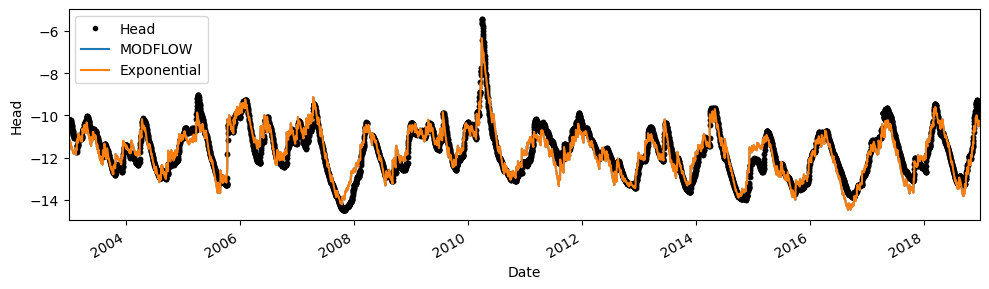

In [14]:
ax = ml.plot(figsize=(10, 3))  # Pastas-Modflow
mlexp.plot(ax=ax)  # Pastas-Exponential
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles[0:2] + handles[3:],
    labels[0:1] + ["MODFLOW", "Exponential"],
    loc="upper left",
)